In [6]:
# 데이터 측정 기간 : 최신성 신뢰도 -> 2016 ~ 2018년
# 데이터 비교 데이터 : olist (브라질 내 유사 플랫폼 비즈니스 Top 5)
# 얼마나 많은 고객이 있는가? 96,096명
# 고객은 주로 어디에 살고 있는가? sao paulo > rio de janeiro > belo horizonte
# 고객은 주로 어떤 결제방법을 선택하고 있는가? credit_card > boleto > voucher
# (월별) 평균 결제액은 얼마일까? 768,619원 (브라질 화폐단위) > 2017년 11월 최고매출 달성 월
# 데이터 => 측정 기준 (많은지, 적은지 결정)
# 데이터 => 비교 대상 (좋은, 안좋은)
# 쇼핑몰 결제 -> 상품 판매가 + 배송비 => 결제단계 // 변수 (생일쿠폰, 고객등급 할인률적용, 시즌별 할인률적용)
# 쇼핑몰 결제 -> 상품출고 승인 -> 택배 -> 택배기사 -> 소비

# 일.주.월별 판매 트랜드?
# 어떤 카테고리가 가장 많은 상품이 판매되었을까?

In [1]:
import pandas as pd

PATH = "00_data"

In [2]:
products = pd.read_csv(f"{PATH}/olist_products_dataset.csv", encoding="utf-8-sig")
customers= pd.read_csv(f"{PATH}/olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}/olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}/olist_order_items_dataset.csv", encoding="utf-8-sig")
payments = pd.read_csv(f"{PATH}/olist_order_payments_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}/olist_order_reviews_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}/olist_orders_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}/olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}/product_category_name_translation.csv", encoding="utf-8-sig")

In [3]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
orders.shape

(99441, 8)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
orders.isnull().sum() # 실제 구매 후 중간에 돌아오거나, 단순변심으로 인한 취.반품 존재 가능여부!!

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
orders = orders.dropna() # drop not available : 사용불가능한 값을 버리겠다

In [12]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [13]:
orders.info() # 99441 -> 96461

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [14]:
payments.shape

(103886, 5)

In [15]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [16]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [ ]:
# 서로 다른 데이터프레임을 병합하고자 할 때, 순서
# 1) 데이터프레임 내 결측치 값 존재 확인 -> 제거
# 2) 데이터프레임을 연결할 수 있는 FK 확인 -> order_id
# 3) FK가 각 데이터 프레임 내 중복값을 가지고 있는지, 고유한 값 유지 확인

In [18]:
orders["order_id"].value_counts().max()

1

In [20]:
payments["order_id"].value_counts().max()

29

In [21]:
payments = payments.groupby("order_id").sum()

In [27]:
payments = payments.reset_index()

In [28]:
payments["order_id"].value_counts().max()

1

In [29]:
payments.shape # orders 96461 : payments 99440

(99440, 5)

In [30]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id", how="left")

In [31]:
merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6.0,credit_cardvouchervoucher,3.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,credit_card,1.0,28.62


In [32]:
merged_order.shape

(96461, 12)

In [33]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96461 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96461 non-null  object 
 1   customer_id                    96461 non-null  object 
 2   order_status                   96461 non-null  object 
 3   order_purchase_timestamp       96461 non-null  object 
 4   order_approved_at              96461 non-null  object 
 5   order_delivered_carrier_date   96461 non-null  object 
 6   order_delivered_customer_date  96461 non-null  object 
 7   order_estimated_delivery_date  96461 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 8.8+ MB

In [34]:
merged_order = merged_order.dropna()

In [35]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96460 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 9.6+ MB


In [36]:
merged_order.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
dtype: int64

In [37]:
merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6.0,credit_cardvouchervoucher,3.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,credit_card,1.0,28.62


In [38]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96460 entries, 0 to 96460
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  float64
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  float64
 11  payment_value                  96460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 9.6+ MB


In [39]:
# 날짜에 따른 결제금액을 시계열차트로 정렬해서 시각화!!!
# 해당 데이터의 타입이 문자가 아닌 날짜타입 되어야함!!!
# object => 문자 -> datetime => 날짜타입 변경!!!!

import pandas as pd

df = pd.DataFrame({
    "order": [
        "2020-01-01 07:10:00",
        "2020-01-08 07:20:30",
        "2020-02-20 11:20:00",
        "2020-02-20 04:40:50",
        "2020-02-28 12:10:20",
        "2019-01-10 17:23:50",
        "2019-06-20 22:27:50",
        "2019-06-20 21:15:59",
        "2019-12-10 21:15:59"
    ]
})

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   order   9 non-null      object
dtypes: object(1)
memory usage: 204.0+ bytes


In [43]:
import pandas as pd

df["order"] = pd.to_datetime(df["order"], format="%Y-%m-%d %H:%M:%S", errors="raise")

### to_datetime() -> 날짜 옵션목록

- %y : 연도를 2글자 표기
- %Y : 연도를 4글자 표기
- %m : 월을 2글자 표기 (01~12)
- %d : 일을 2글자 표기 (01~31)
- %H : 시간을 24시간 기준표기 (00~23)
- %M : 분을 2글자 표기 (00~59)
- %S : 초를 2글자 표기 (00~59)

- errors : 만약 날짜형태로 값을 바꾸기에 불충족한 조건 문자열
- errors=ignore(무시하고 그냥 진행) | raise(에러를 표기하고 나한테 알려줘) | coerce(에러를 NaT 형태로 값을 변환, 진행)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   order   9 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 204.0 bytes


In [45]:
df

,order
0,2020-01-01 07:10:00
1,2020-01-08 07:20:30
2,2020-02-20 11:20:00
3,2020-02-20 04:40:50
4,2020-02-28 12:10:20
5,2019-01-10 17:23:50
6,2019-06-20 22:27:50
7,2019-06-20 21:15:59
8,2019-12-10 21:15:59


In [6]:
import pandas as pd

# orders.shape
# orders.info()
orders = orders.dropna()

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
# payments
# payments.shape
# payments.info()
payments = payments.groupby("order_id").sum()

In [14]:
# payments.head()
payments = payments.reset_index()

In [15]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04
...,...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,1,boleto,1,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,1,boleto,1,386.53
99437,fffce4705a9662cd70adb13d4a31832d,1,credit_card,3,116.85
99438,fffe18544ffabc95dfada21779c9644f,1,credit_card,3,64.71


In [16]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id")

In [17]:
# 지난시간에 연습했던 문자열 타입의 날짜를 본연의 날짜 타입으로 변경 -> 시각화

merged_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,6,credit_cardvouchervoucher,3,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,credit_card,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,credit_card,1,28.62


In [18]:
merged_order.shape

(96460, 12)

In [19]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96460 non-null  object 
 1   customer_id                    96460 non-null  object 
 2   order_status                   96460 non-null  object 
 3   order_purchase_timestamp       96460 non-null  object 
 4   order_approved_at              96460 non-null  object 
 5   order_delivered_carrier_date   96460 non-null  object 
 6   order_delivered_customer_date  96460 non-null  object 
 7   order_estimated_delivery_date  96460 non-null  object 
 8   payment_sequential             96460 non-null  int64  
 9   payment_type                   96460 non-null  object 
 10  payment_installments           96460 non-null  int64  
 11  payment_value                  96460 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usag

In [20]:
merged_order["order_purchase_timestamp"] = pd.to_datetime(merged_order["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [21]:
merged_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96460 entries, 0 to 96459
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96460 non-null  object        
 1   customer_id                    96460 non-null  object        
 2   order_status                   96460 non-null  object        
 3   order_purchase_timestamp       96460 non-null  datetime64[ns]
 4   order_approved_at              96460 non-null  object        
 5   order_delivered_carrier_date   96460 non-null  object        
 6   order_delivered_customer_date  96460 non-null  object        
 7   order_estimated_delivery_date  96460 non-null  object        
 8   payment_sequential             96460 non-null  int64         
 9   payment_type                   96460 non-null  object        
 10  payment_installments           96460 non-null  int64         
 11  payment_value  

In [22]:
merged_order_payement_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [24]:
merged_order_payement_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62


In [25]:
merged_order_payement_date = merged_order_payement_date.set_index("order_purchase_timestamp")

In [26]:
merged_order_payement_date

,payment_value
order_purchase_timestamp,
2017-10-02 10:56:33,38.71
2018-07-24 20:41:37,141.46
2018-08-08 08:38:49,179.12
2017-11-18 19:28:06,72.20
2018-02-13 21:18:39,28.62
...,...
2017-03-09 09:54:05,85.08
2018-02-06 12:58:58,195.00
2017-08-27 14:46:43,271.01


In [30]:
merged_order_payement_date

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,38.71
1,2018-07-24 20:41:37,141.46
2,2018-08-08 08:38:49,179.12
3,2017-11-18 19:28:06,72.20
4,2018-02-13 21:18:39,28.62
...,...,...
96455,2017-03-09 09:54:05,85.08
96456,2018-02-06 12:58:58,195.00
96457,2017-08-27 14:46:43,271.01
96458,2018-01-08 21:28:27,441.16


In [29]:
merged_order_payement_date = merged_order_payement_date.reset_index()

In [31]:
# pandas 라이브러리 모듈 > Grouper 기능
# groupby -> 동일한 값을 가지고 있다는 전제, 그룹핑을 하는 것
# 2026-01-01 ~ 2026-01-31 (그룹)

import pandas as pd

merged_order_month_sum = merged_order_payement_date.groupby(pd.Grouper(key="order_purchase_timestamp", freq="ME")).sum()

In [32]:
merged_order_month_sum

,payment_value
order_purchase_timestamp,
2016-10-31,47271.20
2016-11-30,0.00
2016-12-31,19.62
2017-01-31,127430.74
2017-02-28,269458.98
2017-03-31,414369.39
2017-04-30,390952.18
2017-05-31,566872.73
2017-06-30,490225.60


### Grouper 집계 단위

1. ME : Month End (frequency)
2. QE : Quarter End (frequency)
3. YE : Year End (frequency)
4. D : Calendar Day (frequency)
5. h : Hourly (frequency)
6. min : Minutely (frequency)
7. s : Secondly (frequency)

In [33]:
import pandas as pd

# 특정 시점 부터 특정 시점 까지의 데이터를 집계해서 분석하고자 할 때
# date_range() // range(n) => n갯수만큼의 값을 생성 => 0~n-1, 
pd.date_range(start="2025-01-01", end="2025-12-31") # 파이썬 리스트 | 문자열 (슬라이스)

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

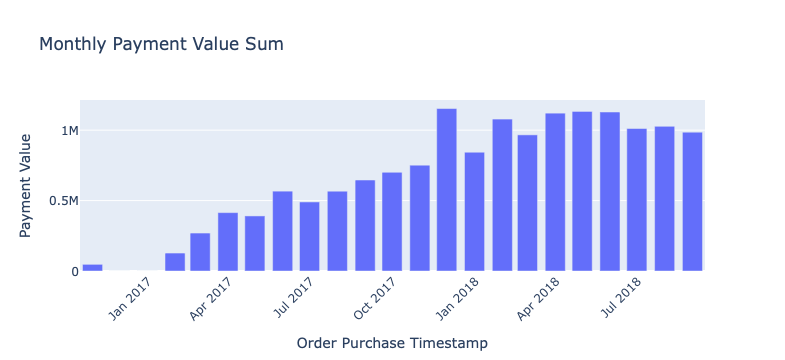

In [37]:
import plotly.express as px

fig = px.bar(
    x = merged_order_month_sum.index,
    y = merged_order_month_sum["payment_value"],
    title = "Monthly Payment Value Sum",
    labels = {
        "x" : "Order Purchase Timestamp",
        "y" : "Payment Value",
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [38]:
merged_order_month_sum["payment_value"].mean() # 평균 모순 함정

np.float64(670420.9934782608)

In [39]:
merged_order_month_sum["payment_value"]

order_purchase_timestamp
2016-10-31      47271.20
2016-11-30          0.00
2016-12-31         19.62
2017-01-31     127430.74
2017-02-28     269458.98
2017-03-31     414369.39
2017-04-30     390952.18
2017-05-31     566872.73
2017-06-30     490225.60
2017-07-31     566403.93
2017-08-31     646000.61
2017-09-30     700976.01
2017-10-31     751140.27
2017-11-30    1153393.22
2017-12-31     843199.17
2018-01-31    1078606.86
2018-02-28     966554.97
2018-03-31    1120678.00
2018-04-30    1132933.95
2018-05-31    1128836.69
2018-06-30    1011561.35
2018-07-31    1027383.10
2018-08-31     985414.28
Freq: ME, Name: payment_value, dtype: float64

In [42]:
# 이상치(outlier)를 제외한 값들의 평균치
merged_order_month_sum["payment_value"][3:].mean()

np.float64(768619.6014999999)

In [44]:
# 최대거래액을 기록한 월

merged_order_month_sum[merged_order_month_sum["payment_value"] == merged_order_month_sum["payment_value"].max()]

,payment_value
order_purchase_timestamp,
2017-11-30,1153393.22
